In [38]:
import pandas as pd
file_path =r'C:\Users\ASUS\Downloads\idx ds-challenge 2b.csv'
df = pd.read_csv(file_path)
df

,customer_id,age,job,marital,education,years_as_customer,avg_monthly_balance,total_products_owned,housing_loan,personal_loan,credit_card,investment_experience,contact_channel,relationship_manager_contact,subscription
0,1,46,management,married,tertiary,12,18000000,4,no,no,yes,yes,cellular,yes,yes
1,2,34,technician,married,secondary,6,5200000,2,yes,no,yes,no,cellular,no,no
2,3,58,retired,married,primary,20,32000000,5,no,no,no,yes,telephone,yes,yes
3,4,29,admin,single,secondary,3,2800000,1,no,no,no,no,cellular,no,no
4,5,42,self-employed,married,tertiary,10,15000000,3,yes,yes,yes,yes,cellular,yes,yes
5,6,37,services,married,secondary,7,6400000,2,yes,no,yes,no,cellular,no,no
6,7,50,entrepreneur,married,tertiary,15,24000000,4,no,no,yes,yes,cellular,yes,yes
7,8,31,student,single,secondary,2,1700000,1,no,no,no,no,cellular,no,no
8,9,45,management,divorced,tertiary,11,19500000,3,no,no,yes,yes,cellular,yes,yes
9,10,39,technician,married,secondary,8,7200000,2,yes,no,yes,no,telephone,no,no


In [39]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
customer_id                     0
age                             0
job                             0
marital                         0
education                       0
years_as_customer               0
avg_monthly_balance             0
total_products_owned            0
housing_loan                    0
personal_loan                   0
credit_card                     0
investment_experience           0
contact_channel                 0
relationship_manager_contact    0
subscription                    0
dtype: int64

Total missing: 0


In [40]:
df = df.drop('customer_id', axis=1)

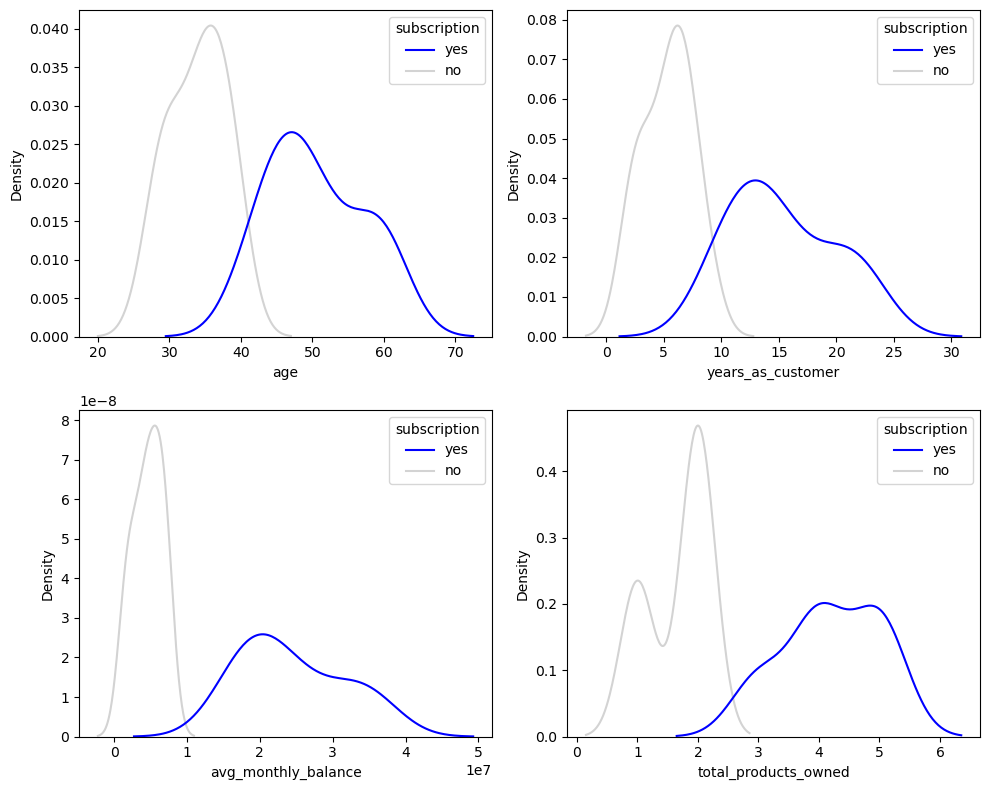

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

n = len(num_cols)
graph_cols = 2
graph_rows = math.ceil(n / graph_cols)

# Fitting plot agar ukurannya maksimal
fig, axes = plt.subplots(graph_rows, graph_cols, figsize=(5*graph_cols, 4*graph_rows))
axes = axes.flatten()

# Melakukan plot terhadap subscription terhadap masing masing variabel
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='subscription', ax=axes[i], palette = {'yes': 'blue', 'no': 'lightgray'})

# menghapus plot yang tidak digunakan
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [42]:
import numpy as np

cols = ['age', 'years_as_customer', 'avg_monthly_balance', 'total_products_owned']

results = {}

# cari thresold dengan nilai total subscription yes - no tertinggi
for col in cols:
    values = np.sort(df[col].dropna().unique())
    scores = []

    for t in values:
        yes = df[(df[col] >= t) & (df['subscription'] == 'yes')].shape[0]
        no  = df[(df[col] >= t) & (df['subscription'] == 'no')].shape[0]
        scores.append(yes - no)
    best_idx = np.argmax(scores)
    best_threshold = values[best_idx]

    results[col] = best_threshold
print(results)

{'age': 41, 'years_as_customer': 9, 'avg_monthly_balance': 15000000, 'total_products_owned': 3}


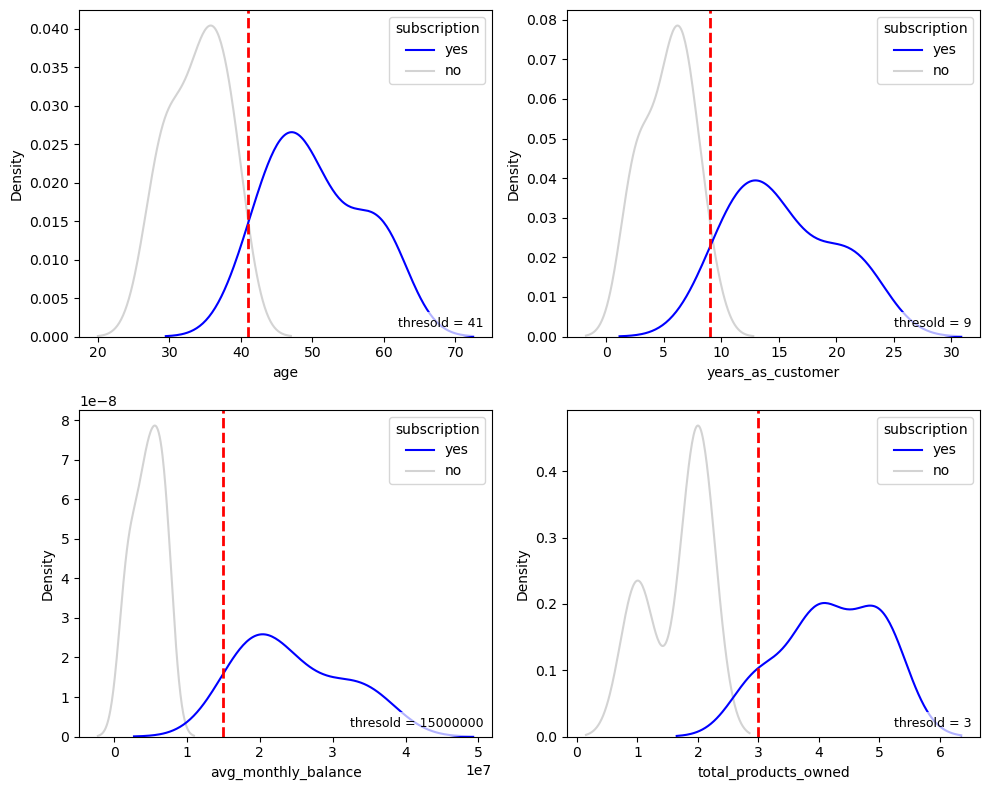

In [43]:
graph_rows = math.ceil(n / graph_cols)

fig, axes = plt.subplots(graph_rows, graph_cols, figsize=(5*graph_cols, 4*graph_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='subscription', ax=axes[i], palette = {'yes': 'blue', 'no': 'lightgray'})
    if col in results:
        axes[i].axvline(x=results[col], color='red', linestyle='--', linewidth=2)
        axes[i].text(0.98, 0.02, f"thresold = {results[col]}",transform=axes[i].transAxes, ha='right', va='bottom', fontsize=9,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

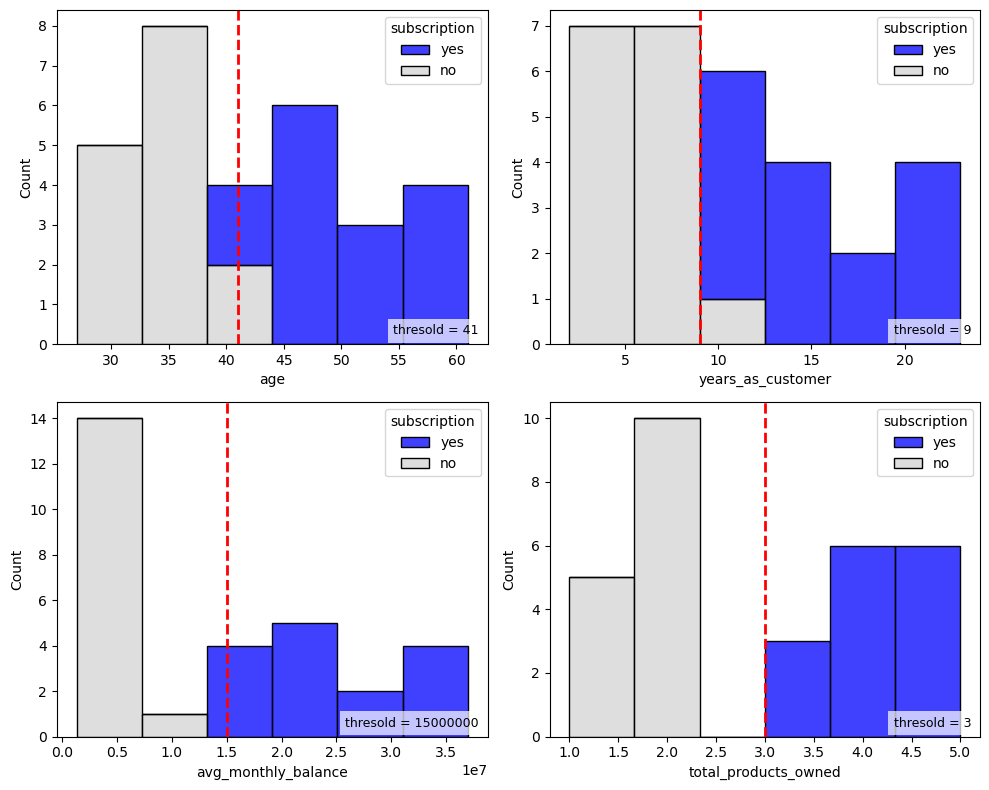

In [44]:
graph_rows = math.ceil(n / graph_cols)

fig, axes = plt.subplots(graph_rows, graph_cols, figsize=(5*graph_cols, 4*graph_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Membuat Plot stacked bar chart
    sns.histplot(data=df, x=col, hue='subscription', ax=axes[i], multiple='stack', palette = {'yes': 'blue', 'no': 'lightgray'})
    if col in results:
        # Menambah garis thresold 
        axes[i].axvline(x=results[col], color='red', linestyle='--', linewidth=2)
        axes[i].text(0.98, 0.02, f"thresold = {results[col]}",transform=axes[i].transAxes, ha='right', va='bottom', fontsize=9,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X = df[cols]
y = (df['subscription'] == 'yes').astype(int)

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# evaluasi
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.86      0.92         7

    accuracy                           0.92        12
   macro avg       0.92      0.93      0.92        12
weighted avg       0.93      0.92      0.92        12



In [46]:
from sklearn.tree import export_text

tree_rules = export_text(model, feature_names=cols)
print(tree_rules)

|--- age <= 41.00
|   |--- class: 0
|--- age >  41.00
|   |--- class: 1



In [47]:
# Mengidentifikasi korelasi antar fitur numerik
df[num_cols].corr()

,age,years_as_customer,avg_monthly_balance,total_products_owned
age,1.000000,0.994003,0.983527,0.968631
years_as_customer,0.994003,1.000000,0.985062,0.961800
avg_monthly_balance,0.983527,0.985062,1.000000,0.967070
total_products_owned,0.968631,0.961800,0.967070,1.000000


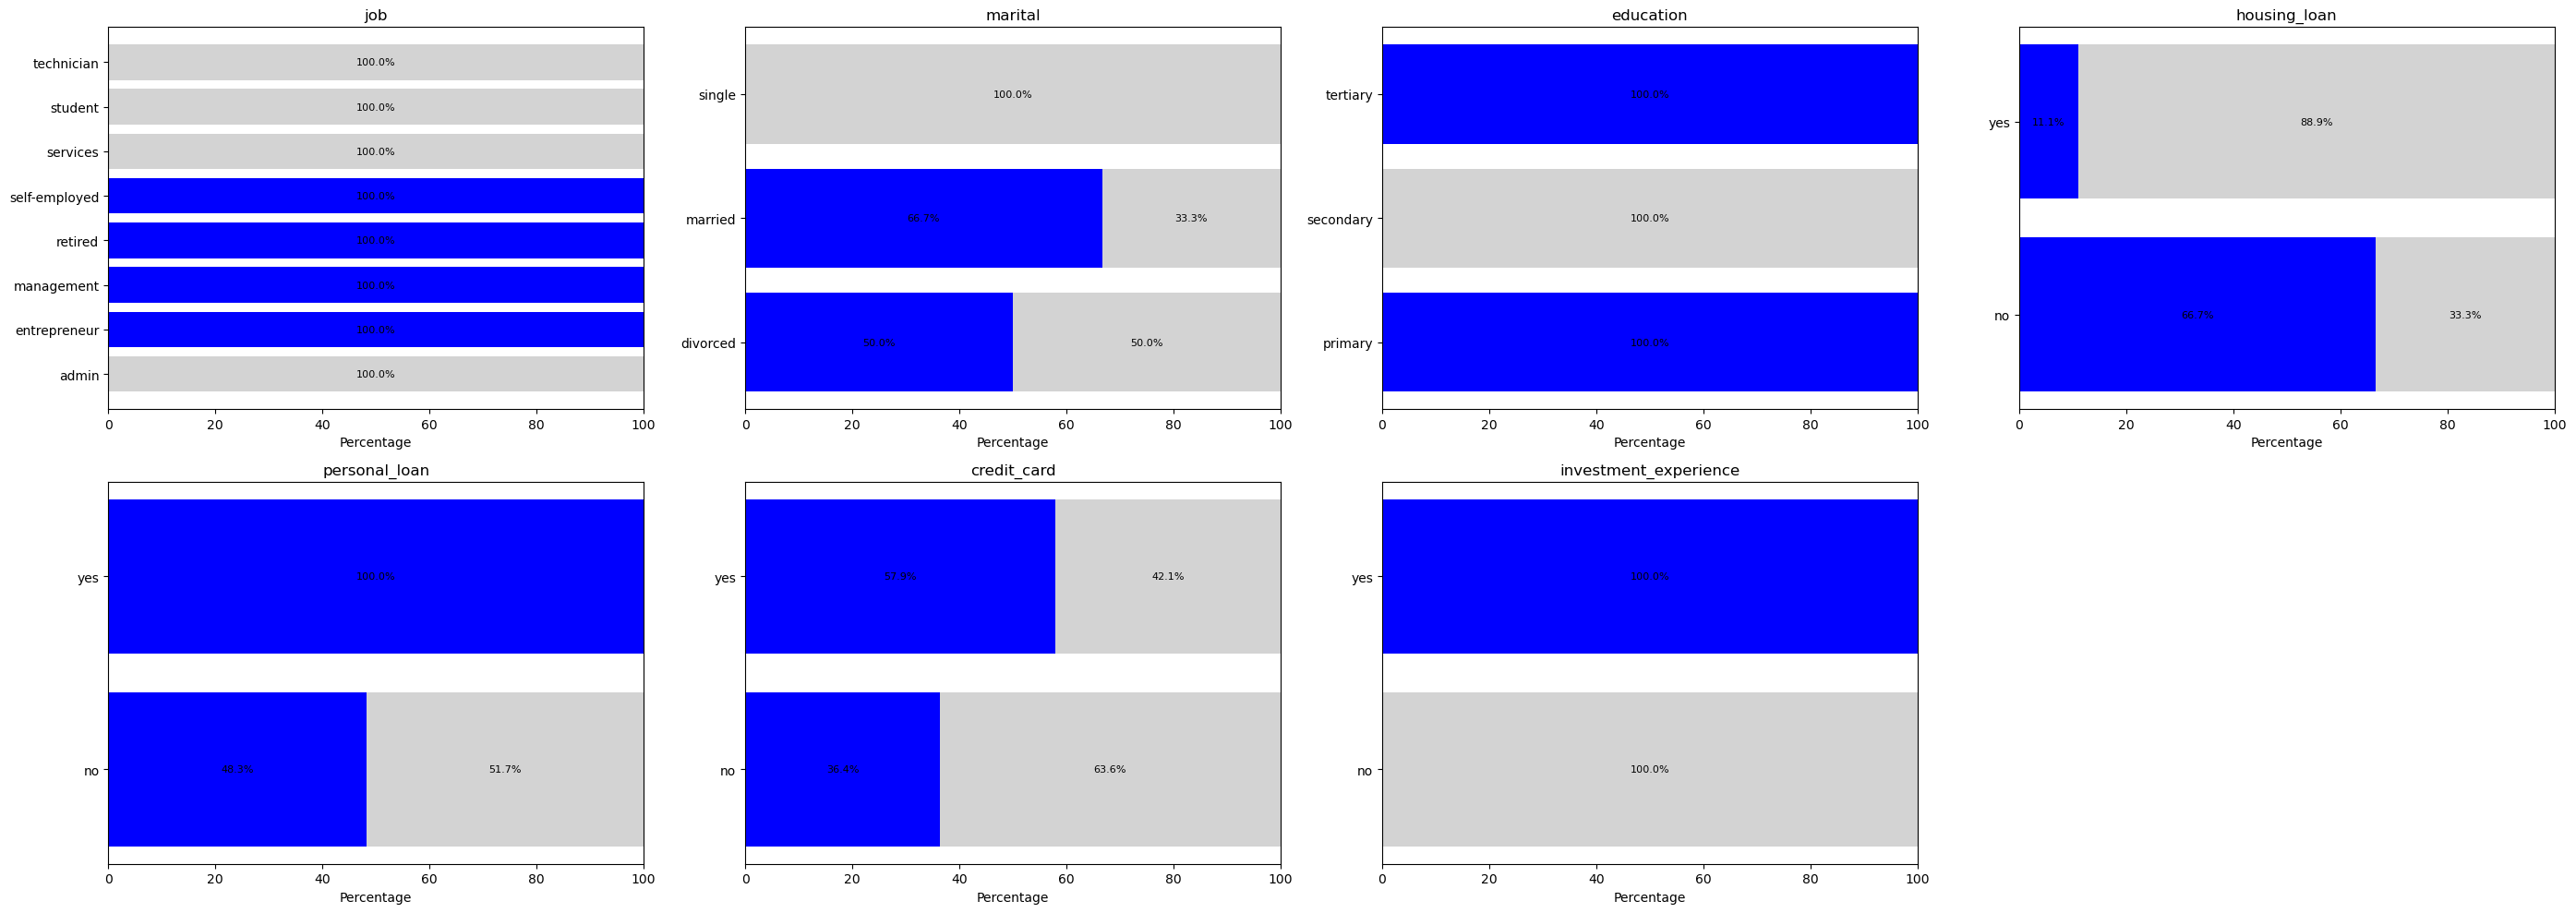

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_cols = df.select_dtypes(include=['object', 'category']).drop(columns=['subscription','relationship_manager_contact','contact_channel']).columns

n = len(cat_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(7*cols, 5*rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)

    # Membuat tabel persentase
    ct = pd.crosstab(df[col], df['subscription'], normalize='index') * 100

    # Memastikan order
    ct = ct[['yes', 'no']] if 'yes' in ct.columns else ct

    left = np.zeros(len(ct))

    # warna plot
    colors = {'yes': 'blue', 'no': 'lightgray'}

    # Melakukan plot horizontal stacked bar
    for sub in ct.columns:
        values = ct[sub].values
        plt.barh(ct.index, values, left=left, color=colors[sub], label=sub)

        # menambah label persentase
        for j in range(len(values)):
            if values[j] > 5:  # kalau nilai persentase kecil maka tidak ditulis agar tidak menganggu plot
                plt.text(left[j] + values[j]/2, j, f"{values[j]:.1f}%",
                         ha='center', va='center', fontsize=8)

        left += values

    plt.title(col)
    plt.xlim(0, 100)
    plt.xlabel("Percentage")

plt.tight_layout()
plt.show()

In [49]:
df = df.drop(['contact_channel','relationship_manager_contact'], axis=1)

In [50]:
# binary mapping
binary_cols = ['housing_loan', 'personal_loan', 'credit_card', 'investment_experience', 'subscription']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# one-hot
df = pd.get_dummies(df, columns=['job', 'marital','education'], drop_first=True)
X = df.drop(['subscription','age', 'years_as_customer', 'avg_monthly_balance', 'total_products_owned'], axis=1)
y = df['subscription']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# =========================
# 3. MODEL
# =========================

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# =========================
# 4. EVALUASI
# =========================

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# =========================
# 5. RULE TREE
# =========================

tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

|--- education_secondary <= 0.50
|   |--- class: 1
|--- education_secondary >  0.50
|   |--- class: 0

